# 2_GradientBoosting_Optimizacion

**Proyecto:** FinanceGuard — Avance #2  


En este notebook comparo Random Forest, XGBoost, LightGBM y CatBoost, y construyo un ensamblado (Stacking) usando esos modelos como nivel 1 y una regresión logística como meta-learner.  
Optimizo hiperparámetros solo para XGBoost usando GridSearch. Uso `StratifiedKFold` por el desbalance y reporto métricas relevantes: ROC-AUC, PR-AUC, Precision, Recall y F1.


In [1]:
# 0) Librerías y configuración inicial
import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
)
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

sns.set_style("whitegrid")
%matplotlib inline

print("xgboost version:", xgb.__version__)


xgboost version: 3.1.1


## 1) Cargo datos y revisión inicial

Cargo el CSV con los datos y hago una revisión rápida: formas, nulos y distribución de la variable objetivo `churn`.

In [2]:
df = pd.read_csv('C:\\Users\\Davem\\Downloads\\DATA SCIENCE\\Modulo_4\\ProyectoM4_Lourdes_Diamela_Alarcon_DSFT01\\Churn_Modelling.csv')
print("Shape (filas, columnas):", df.shape)
display(df.head())

# Normalizo nombre de target si viene como 'Exited'
if 'Exited' in df.columns and 'churn' not in df.columns:
    df.rename(columns={'Exited':'churn'}, inplace=True)

if 'churn' not in df.columns:
    raise ValueError("No encontré la columna objetivo 'churn' ni 'Exited' en el dataset.")

print("\nNulos por columna:")
display(df.isna().sum())

print("\nDistribución target (counts & proportion):")
display(df['churn'].value_counts(), (df['churn'].value_counts()/len(df)).round(3))


Shape (filas, columnas): (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Nulos por columna:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
churn              0
dtype: int64


Distribución target (counts & proportion):


churn
0    7963
1    2037
Name: count, dtype: int64

churn
0    0.796
1    0.204
Name: count, dtype: float64

## 2) EDA breve

Hago gráficos simples para entender la distribución de variables clave (edad, balance, género, geografía). Esto me ayuda a detectar sesgos y plantear qué variables escalar o transformar.


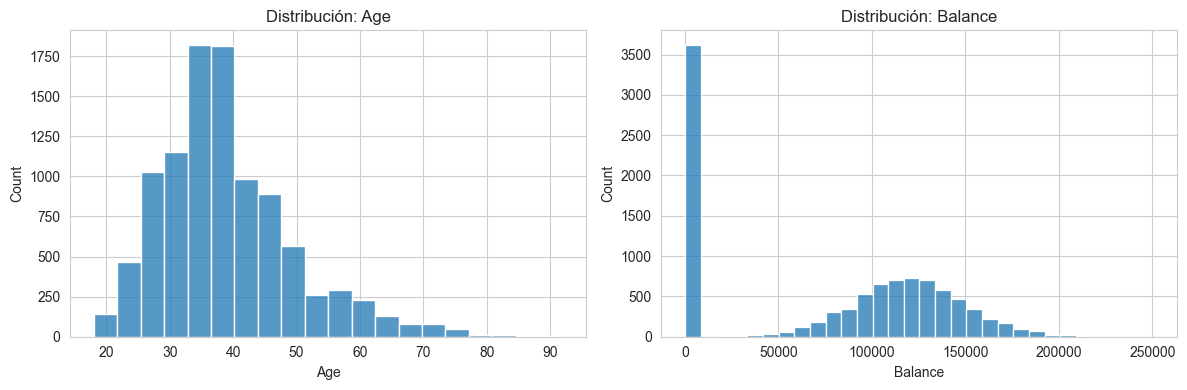

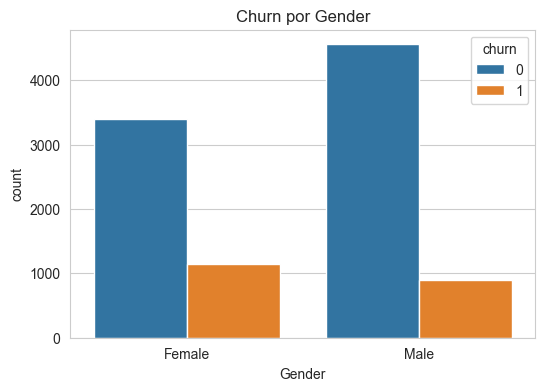

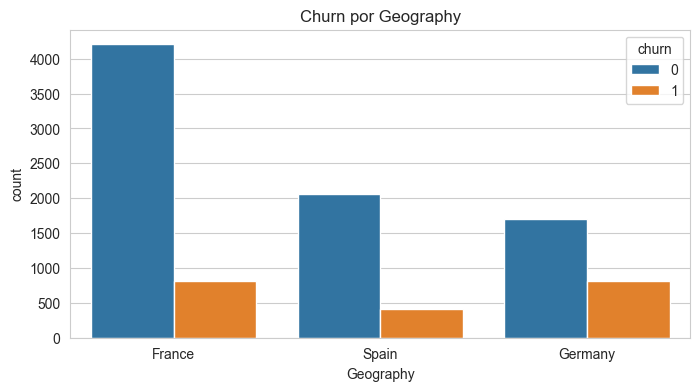

In [3]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
if 'Age' in df.columns:
    sns.histplot(df['Age'], bins=20)
    plt.title("Distribución: Age")
else:
    plt.text(0.5, 0.5, "No hay columna Age", ha='center')

plt.subplot(1,2,2)
if 'Balance' in df.columns:
    sns.histplot(df['Balance'], bins=30)
    plt.title("Distribución: Balance")
else:
    plt.text(0.5, 0.5, "No hay columna Balance", ha='center')
plt.tight_layout()
plt.show()

if 'Gender' in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x='Gender', hue='churn', data=df)
    plt.title("Churn por Gender")
    plt.show()

if 'Geography' in df.columns:
    plt.figure(figsize=(8,4))
    sns.countplot(x='Geography', hue='churn', data=df)
    plt.title("Churn por Geography")
    plt.show()


## 3) Limpieza y encoding

Hago limpieza básica: quito columnas irrelevantes (IDs), relleno nulos simples, convierto `Gender` a 0/1 y hago one-hot de `Geography` sin `drop_first` para que cada país aparezca explícitamente (quiero poder interpretar Francia directamente).


In [4]:
df_proc = df.copy()

# Eliminar columnas irrelevantes
for col in ['RowNumber','CustomerId','Surname']:
    if col in df_proc.columns:
        df_proc.drop(col, axis=1, inplace=True)

# Relleno simple: numéricos -> mediana; categóricos -> moda
for c in df_proc.columns:
    if df_proc[c].isna().sum() > 0:
        if pd.api.types.is_numeric_dtype(df_proc[c]):
            df_proc[c].fillna(df_proc[c].median(), inplace=True)
        else:
            df_proc[c].fillna(df_proc[c].mode()[0], inplace=True)

# Encoding Gender y Geography
if 'Gender' in df_proc.columns:
    df_proc['Gender'] = df_proc['Gender'].map({'Female':0, 'Male':1}).fillna(0)

if 'Geography' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['Geography'], drop_first=False)

print("Preprocesamiento básico completado. Shape:", df_proc.shape)
display(df_proc.head())


Preprocesamiento básico completado. Shape: (10000, 13)


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,churn,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,True,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,False,True


## 4) Split train/test y escalado

Divido los datos en train/test (80/20) de forma estratificada para mantener la proporción de churn. Escalo las columnas numéricas con `StandardScaler` ajustado solo en train.


In [5]:
# Separar X e y
X = df_proc.drop('churn', axis=1)
y = df_proc['churn']

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Columnas numéricas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print("Columnas numéricas detectadas:", num_cols)

# Escalado
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()

X_train.loc[:, num_cols] = scaler.fit_transform(X_train.loc[:, num_cols])
X_test.loc[:, num_cols] = scaler.transform(X_test.loc[:, num_cols])

print("Split y escalado completados. Train shape:", X_train.shape, "Test shape:", X_test.shape)


Columnas numéricas detectadas: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Split y escalado completados. Train shape: (8000, 12) Test shape: (2000, 12)


## 5) Asegurar que los datos son numéricos

Algunos modelos y librerías son estrictos con tipos. Convierto columnas `object` a numérico si es posible y relleno NaNs que pudieran aparecer durante la conversión.


In [6]:
def ensure_numeric(df_in):
    df_out = df_in.copy()
    for c in df_out.columns:
        if df_out[c].dtype == 'object' or str(df_out[c].dtype).startswith('category'):
            df_out[c] = pd.to_numeric(df_out[c], errors='coerce')
        if df_out[c].dtype == 'bool':
            df_out[c] = df_out[c].astype(int)
    df_out = df_out.fillna(0)
    return df_out

X_train = ensure_numeric(X_train)
X_test = ensure_numeric(X_test)

print("Verificación tipos (X_train):")
display(X_train.dtypes.value_counts())


Verificación tipos (X_train):


float64    9
int64      3
Name: count, dtype: int64

## 6) Funciones de evaluación

Defino funciones para calcular ROC-AUC en CV, PR-AUC y para mostrar métricas en test (ROC-AUC, PR-AUC, Precision, Recall, F1).PR-AUC es útil cuando las clases están desbalanceadas.


In [15]:
def cv_roc_auc(model, X, y, cv=5):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, scoring='roc_auc', cv=skf, n_jobs=-1)
    return scores.mean(), scores.std()

def pr_auc_test(y_true, y_scores):
    p, r, _ = precision_recall_curve(y_true, y_scores)
    return auc(r, p)

def evaluate_on_test(model, X_test, y_test):
    # Todos los modelos usados aquí implementan predict_proba
    y_proba = model.predict_proba(X_test)[:,1]
    y_pred = (y_proba >= 0.5).astype(int)
    roc = roc_auc_score(y_test, y_proba)
    pr = pr_auc_test(y_test, y_proba)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"ROC AUC: {roc:.4f} | PR AUC: {pr:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title('Confusion matrix')
    plt.show()
    return {'roc_auc':roc, 'pr_auc':pr, 'precision':prec, 'recall':rec, 'f1':f1}


## 7) Random Forest — baseline

Entreno RandomForest con `class_weight='balanced'` para mitigar el desbalance. Lo uso como referencia inicial.


Tiempo entrenamiento RF: 1.5s
CV ROC AUC (RF): (np.float64(0.8528982192216198), np.float64(0.012274299703216151))
ROC AUC: 0.8511 | PR AUC: 0.6774 | Precision: 0.7708 | Recall: 0.4545 | F1: 0.5719

Classification report:
               precision    recall  f1-score   support

           0     0.8739    0.9655    0.9174      1593
           1     0.7708    0.4545    0.5719       407

    accuracy                         0.8615      2000
   macro avg     0.8223    0.7100    0.7446      2000
weighted avg     0.8529    0.8615    0.8471      2000



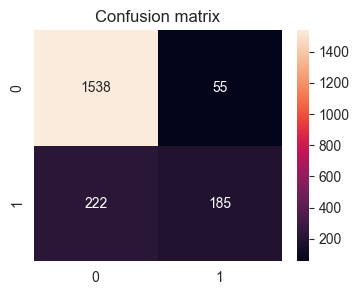


Top 15 features RF:


Age                  0.250860
Balance              0.142329
EstimatedSalary      0.137783
CreditScore          0.132961
NumOfProducts        0.129905
Tenure               0.082127
IsActiveMember       0.036140
Geography_Germany    0.026236
Gender               0.021266
HasCrCard            0.018183
Geography_France     0.012262
Geography_Spain      0.009949
dtype: float64

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')

t0 = time.time()
rf.fit(X_train, y_train)
print("Tiempo entrenamiento RF: {:.1f}s".format(time.time() - t0))

print("CV ROC AUC (RF):", cv_roc_auc(rf, X_train, y_train, cv=5))
rf_metrics = evaluate_on_test(rf, X_test, y_test)

fi_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 features RF:")
display(fi_rf.head(15))


## 8) XGBoost — GridSearchCV (optimizacion)

Aplico `GridSearchCV` sobre `XGBClassifier` buscando `n_estimators`, `max_depth` y `learning_rate`.  



In [9]:
# Preparar modelo base para GridSearch
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42)

# Grid 
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.1]
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='roc_auc', cv=skf, n_jobs=-1, verbose=2)

t0 = time.time()
grid.fit(X_train, y_train)
print("GridSearch time: {:.1f}s".format(time.time() - t0))
print("Mejor combo:", grid.best_params_, "Mejor score (cv):", grid.best_score_)

# Mejor estimador (wrapper sklearn). Lo usaremos para evaluación; para early stopping venimos abajo.
xgb_best = grid.best_estimator_


Fitting 3 folds for each of 8 candidates, totalling 24 fits
GridSearch time: 3.0s
Mejor combo: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100} Mejor score (cv): 0.8615686293296433


### Modo compatible de re-entrenamiento para early stopping

La API de XGBoost puede variar por versión. Para asegurar compatibilidad:
- Si la versión es >= 3.x uso **DMatrix + xgb.train** (early stopping funciona ahí).
- Si la versión es 1.x uso `XGBClassifier.fit(..., early_stopping_rounds=...)`.
- En cualquier caso, dejo el `xgb_best` listo para evaluación y para usar en GridSearch (y creo un XGBClassifier nuevo si hace falta para stacking).


xgboost major.minor: (3, 1)
Usando DMatrix + xgb.train para early stopping (xgboost >= 3.x).

Evaluación XGBoost optimizado:
ROC AUC: 0.8676 | PR AUC: 0.7156 | Precision: 0.7927 | Recall: 0.4791 | F1: 0.5972

Classification report:
               precision    recall  f1-score   support

           0     0.8791    0.9680    0.9214      1593
           1     0.7927    0.4791    0.5972       407

    accuracy                         0.8685      2000
   macro avg     0.8359    0.7236    0.7593      2000
weighted avg     0.8615    0.8685    0.8555      2000



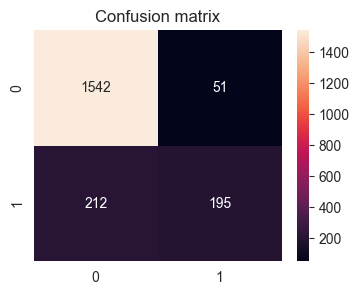

In [10]:
# Detectar versión xgboost y re-entrenar de forma compatible para early stopping si es posible
ver = tuple(int(x) for x in xgb.__version__.split('.')[:2])
print("xgboost major.minor:", ver)

if ver >= (3, 0):
    # Uso DMatrix + xgb.train para early stopping (compatible con 3.x)
    print("Usando DMatrix + xgb.train para early stopping (xgboost >= 3.x).")
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "learning_rate": xgb_best.learning_rate,
        "max_depth": int(xgb_best.max_depth),
        "subsample": getattr(xgb_best, "subsample", 1.0),
        "colsample_bytree": getattr(xgb_best, "colsample_bytree", 1.0),
        "gamma": getattr(xgb_best, "gamma", 0),
        "reg_alpha": getattr(xgb_best, "reg_alpha", 0),
        "reg_lambda": getattr(xgb_best, "reg_lambda", 1),
        "seed": 42
    }
    evals = [(dtrain, "train"), (dval, "valid")]
    booster = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=int(xgb_best.n_estimators),
        evals=evals,
        early_stopping_rounds=20,
        verbose_eval=False
    )
    # wrapper para predict_proba
    class XGBWrapped:
        def __init__(self, booster):
            self.booster = booster
        def predict_proba(self, X):
            d = xgb.DMatrix(X)
            p = self.booster.predict(d)
            return np.vstack([1 - p, p]).T
        def predict(self, X):
            return (self.predict_proba(X)[:,1] >= 0.5).astype(int)
    xgb_best_wrapped = XGBWrapped(booster)
    # usamos xgb_best_wrapped para evaluación; xgb_best sigue existiendo como sklearn estimator
    xgb_to_eval = xgb_best_wrapped
elif ver >= (1, 0):
    # versiones 1.x: early_stopping_rounds en XGBClassifier.fit suele funcionar
    print("Usando XGBClassifier.fit con early_stopping_rounds (xgboost 1.x).")
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
    xgb_best.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], early_stopping_rounds=20, verbose=False)
    xgb_to_eval = xgb_best
else:
    # versiones antiguas: DMatrix + xgb.train
    print("Versión antigua de xgboost detectada (<1.0). Uso xgb.train con DMatrix.")
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)
    dtrain = xgb.DMatrix(X_tr, label=y_tr)
    dval = xgb.DMatrix(X_val, label=y_val)
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "learning_rate": xgb_best.learning_rate,
        "max_depth": int(xgb_best.max_depth),
        "seed": 42
    }
    evals = [(dtrain, "train"), (dval, "valid")]
    booster = xgb.train(params=params, dtrain=dtrain, num_boost_round=int(xgb_best.n_estimators), evals=evals, early_stopping_rounds=20, verbose_eval=False)
    # wrapper
    class XGBWrapped:
        def __init__(self, booster):
            self.booster = booster
        def predict_proba(self, X):
            d = xgb.DMatrix(X)
            p = self.booster.predict(d)
            return np.vstack([1 - p, p]).T
        def predict(self, X):
            return (self.predict_proba(X)[:,1] >= 0.5).astype(int)
    xgb_best_wrapped = XGBWrapped(booster)
    xgb_to_eval = xgb_best_wrapped

# Evaluación del XGBoost optimizado (uso xgb_to_eval)
print("\nEvaluación XGBoost optimizado:")
xgb_metrics = evaluate_on_test(xgb_to_eval, X_test, y_test)


## 9) LightGBM

Entreno LightGBM con parámetros razonables y muestro CV y métricas en test. También muestro la importancia de features.


[LightGBM] [Info] Number of positive: 1630, number of negative: 6370
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.055770 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 864
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203750 -> initscore=-1.363019
[LightGBM] [Info] Start training from score -1.363019
Tiempo entrenamiento LGB: 0.6s
CV ROC AUC (LGB): (np.float64(0.8598275081623022), np.float64(0.011722871370557405))
ROC AUC: 0.8607 | PR AUC: 0.7052 | Precision: 0.7557 | Recall: 0.4865 | F1: 0.5919

Classification report:
               precision    recall  f1-score   support

           0     0.8797    0.9598    0.9180      1593
           1     0.7557    0.4865    0.5919       407

    accuracy                         0.8635      2000
   macro avg     0.8177    0.7232    0.7550      2000
weighted avg  

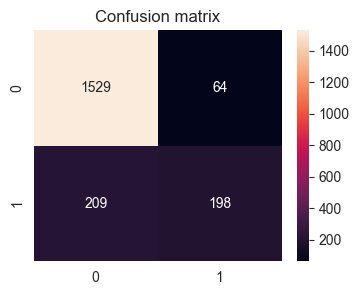


Top 15 features LGB:


EstimatedSalary      1182
CreditScore          1146
Balance              1144
Age                   939
Tenure                451
NumOfProducts         401
IsActiveMember        173
Gender                158
Geography_Germany     148
Geography_France      119
Geography_Spain        79
HasCrCard              60
dtype: int32

In [11]:
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1)

t0 = time.time()
lgb_model.fit(X_train, y_train)
print("Tiempo entrenamiento LGB: {:.1f}s".format(time.time()-t0))

print("CV ROC AUC (LGB):", cv_roc_auc(lgb_model, X_train, y_train, cv=5))
lgb_metrics = evaluate_on_test(lgb_model, X_test, y_test)

fi_lgb = pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 15 features LGB:")
display(fi_lgb.head(15))


## 10) CatBoost

Entreno CatBoost. CatBoost maneja categorías internamente, pero como yo ya hice encoding uso CatBoost como cualquier otro modelo.


Tiempo entrenamiento CatBoost: 4.2s
CV ROC AUC (CatBoost): (np.float64(0.8609480790900598), np.float64(0.010469443947400481))
ROC AUC: 0.8616 | PR AUC: 0.7172 | Precision: 0.7905 | Recall: 0.4914 | F1: 0.6061

Classification report:
               precision    recall  f1-score   support

           0     0.8815    0.9667    0.9222      1593
           1     0.7905    0.4914    0.6061       407

    accuracy                         0.8700      2000
   macro avg     0.8360    0.7291    0.7641      2000
weighted avg     0.8630    0.8700    0.8578      2000



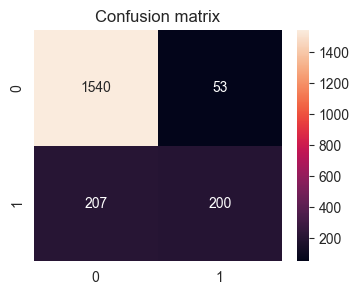


Top 15 features CatBoost:


Age                  19.417899
NumOfProducts        19.268986
Balance              14.300604
CreditScore          11.273895
EstimatedSalary      10.486393
IsActiveMember        6.197982
Tenure                6.068788
Geography_Germany     5.329411
Gender                3.533664
Geography_France      1.499764
Geography_Spain       1.335561
HasCrCard             1.287052
dtype: float64

In [12]:
cat_model = CatBoostClassifier(iterations=500, learning_rate=0.05, verbose=0, random_state=42)

t0 = time.time()
cat_model.fit(X_train, y_train)
print("Tiempo entrenamiento CatBoost: {:.1f}s".format(time.time()-t0))

print("CV ROC AUC (CatBoost):", cv_roc_auc(cat_model, X_train, y_train, cv=5))
cat_metrics = evaluate_on_test(cat_model, X_test, y_test)

try:
    fi_cat = pd.Series(cat_model.get_feature_importance(), index=X_train.columns).sort_values(ascending=False)
    print("\nTop 15 features CatBoost:")
    display(fi_cat.head(15))
except Exception as e:
    print("No pude obtener feature importance de CatBoost:", e)


## 11) Comparación de resultados

Compilo las métricas principales en una tabla para comparar fácilmente los modelos.


,roc_auc,pr_auc,precision,recall,f1
model,,,,,
RandomForest,0.851102,0.677359,0.770833,0.454545,0.571870
XGBoost,0.867603,0.715559,0.792683,0.479115,0.597243
LightGBM,0.860705,0.705171,0.755725,0.486486,0.591928
CatBoost,0.861618,0.717215,0.790514,0.491400,0.606061


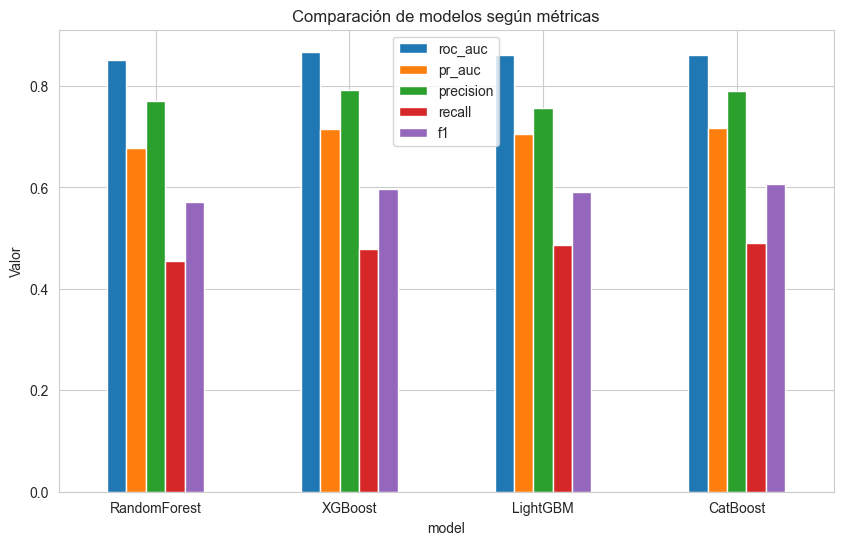

In [13]:
results = pd.DataFrame([
    {'model': 'RandomForest', **rf_metrics},
    {'model': 'XGBoost', **xgb_metrics},
    {'model': 'LightGBM', **lgb_metrics},
    {'model': 'CatBoost', **cat_metrics}
])

results = results.set_index('model')
display(results)

# Gráfico comparativo
results.plot(kind='bar', figsize=(10,6))
plt.title("Comparación de modelos según métricas")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.show()


## 12) Stacking (nivel 1: XGBoost, LightGBM, CatBoost — meta-learner: Regresión Logística)

Para evitar los problemas de clonación con wrappers uso un XGBClassifier nuevo (con los mejores hiperparámetros) entrenado sobre todo el train como base para el stacking. Luego junto con LightGBM y CatBoost construyo el Stacking y lo entreno con `StratifiedKFold` para evitar sobreajuste del meta-learner.


Tiempo entrenamiento Stacking: 14.2s
ROC AUC: 0.8689 | PR AUC: 0.7224 | Precision: 0.5667 | Recall: 0.7101 | F1: 0.6303

Classification report:
               precision    recall  f1-score   support

           0     0.9208    0.8613    0.8900      1593
           1     0.5667    0.7101    0.6303       407

    accuracy                         0.8305      2000
   macro avg     0.7437    0.7857    0.7602      2000
weighted avg     0.8487    0.8305    0.8372      2000



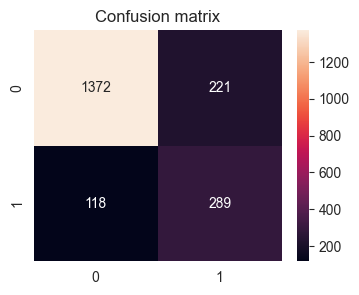


Métricas Stacking:
{'roc_auc': 0.8688858349875299, 'pr_auc': 0.7224315093964065, 'precision': 0.5666666666666667, 'recall': 0.7100737100737101, 'f1': 0.6303162486368593}


In [14]:
# Creo un XGBClassifier limpio para stacking con los mejores hiperparámetros hallados en GridSearch
xgb_for_stack = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    n_estimators=grid.best_params_['n_estimators'],
    max_depth=grid.best_params_['max_depth'],
    learning_rate=grid.best_params_['learning_rate']
)

# Entreno este XGBClassifier en todo el train para usarlo dentro del stack
xgb_for_stack.fit(X_train, y_train)

# Clono (seguro) LightGBM y CatBoost para stacking
lgb_stack = clone(lgb_model)
cat_stack = clone(cat_model)

estimators_stack = [
    ('xgb', xgb_for_stack),
    ('lgb', lgb_stack),
    ('cat', cat_stack)
]

stack = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    passthrough=False
)

t0 = time.time()
stack.fit(X_train, y_train)
print("Tiempo entrenamiento Stacking: {:.1f}s".format(time.time()-t0))

stack_metrics = evaluate_on_test(stack, X_test, y_test)
print("\nMétricas Stacking:")
print(stack_metrics)


## 13) Observaciones finales y próximos pasos

- He comparado RandomForest, XGBoost (optimizado con GridSearch), LightGBM y CatBoost.  
- Construí un stacking usando estos modelos como nivel 1 y regresión logística regularizada como meta-learner.  
- Usé `StratifiedKFold` y métricas relevantes (ROC-AUC, PR-AUC, Precision, Recall, F1).  
- Optuna no se ejecutó aquí (es opcional)
